noisy_signal: MAE=1.390509, MSE=2.711548, RMSE=1.646678
symmetric: MAE=0.117730, MSE=0.021671, RMSE=0.147211
periodic: MAE=0.118358, MSE=0.022717, RMSE=0.150722
smooth: MAE=0.115051, MSE=0.020721, RMSE=0.143947
constant: MAE=0.112599, MSE=0.019429, RMSE=0.139387
zero: MAE=0.150153, MSE=0.082720, RMSE=0.287611
antireflect: MAE=0.108529, MSE=0.017656, RMSE=0.132877
periodization: MAE=0.014008, MSE=0.002196, RMSE=0.046865


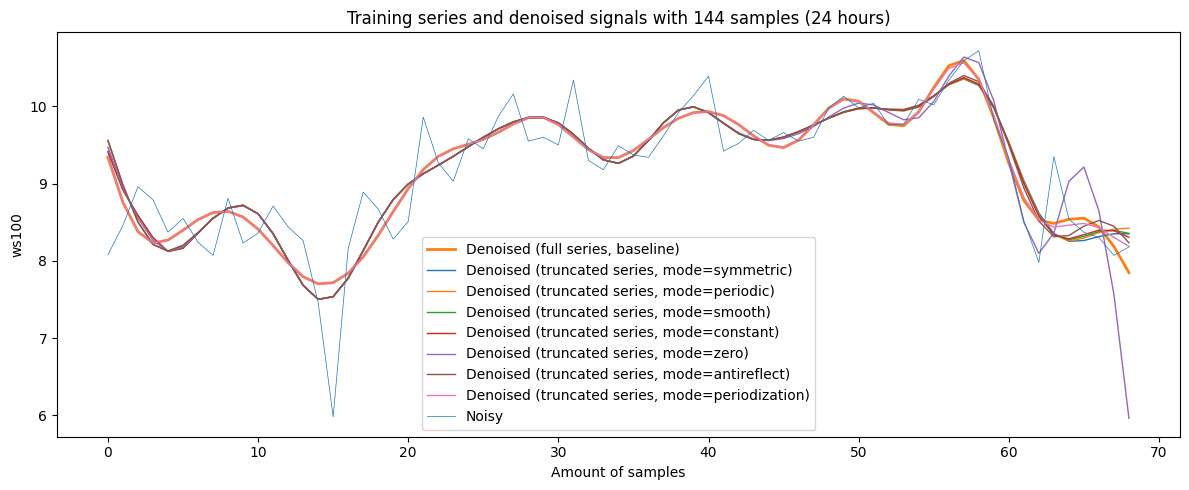

In [8]:
import os
import glob
import ctypes
import site
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pywt  # Biblioteca para transformacoes wavelet
import keras_tuner as kt


variables = pd.read_csv('../data/dataset.csv', index_col=0, parse_dates=True)

samples_count = 6*24
padding = 1600
tail_length = 0.6

target_series = variables['ws100'][:padding + samples_count]
train_size = int(samples_count * 0.8)
train_series = target_series[:train_size+padding]

def wavelet_denoising(signal, wavelet='sym18', mode='antireflect', level=2):
    """
    Aplica técnica de denoising wavelet para reduzir o ruído do sinal
    
    Parâmetros:
    signal: array-like - O sinal de entrada a ser processado
    wavelet: str - O tipo de wavelet a ser utilizado (default: 'sym18')
    mode: str - O modo de decomposição wavelet (default: 'antireflect')
    level: int - O nível de decomposição wavelet (default: 2)
    
    Retorna:
    array-like - Sinal reconstruído após a remoção de ruído
    """
    coeffs = pywt.wavedec(signal, wavelet, mode=mode, level=level)

    sigma = np.median(np.abs(coeffs[-level])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))

    coeffs[1:] = [pywt.threshold(i, value=uthresh, mode='soft') for i in coeffs[1:]]

    reconstructed_signal = pywt.waverec(coeffs, wavelet, mode=mode)
    return reconstructed_signal[:len(signal)]
    
noisy_signal = target_series.values[padding:padding+train_size]
noisy_signal_tail = noisy_signal[-int(len(noisy_signal) * tail_length):]

baseline_signal = wavelet_denoising(target_series.values,mode="periodization")[padding:len(train_series)]
baseline_signal_tail = baseline_signal[-int(len(baseline_signal) * tail_length):]

modes_to_test = ['symmetric', 'periodic', 'smooth', 'constant', 'zero', 'antireflect','periodization']
signals = {}
signal_tails = {}
for mode in modes_to_test:
    signals[mode] = wavelet_denoising(train_series.values, mode=mode)[padding:len(train_series)]
    signal_tails[mode] = signals[mode][-int(len(signals[mode]) * tail_length):]

candidate_signals = {"noisy_signal": noisy_signal, **signal_tails}

baseline = np.asarray(baseline_signal_tail).ravel()

for name, signal in candidate_signals.items():
    current = np.asarray(signal).ravel()
    n = min(len(baseline), len(current))
    diff = current[:n] - baseline[:n]

    mae = np.mean(np.abs(diff))
    mse = np.mean(diff ** 2)
    rmse = np.sqrt(mse)

    print(f"{name}: MAE={mae:.6f}, MSE={mse:.6f}, RMSE={rmse:.6f}")

plt.figure(figsize=(12,5))
plt.plot(baseline_signal_tail, label='Denoised (full series, baseline)', color='C1', linewidth=2)
for mode in modes_to_test:
    plt.plot(signal_tails[mode], label=f'Denoised (truncated series, mode={mode})', linewidth=1)
plt.plot(noisy_signal_tail, label='Noisy', color='C10', linewidth=0.5)
plt.legend()
plt.title(f'Training series and denoised signals with {samples_count} samples ({samples_count//6} hours)')
plt.xlabel('Amount of samples')
plt.ylabel(train_series.name if getattr(train_series, "name", None) else 'Value')
plt.tight_layout()
plt.show()